In [1]:
import spacy  #pode comentar essa linha e a última da célula se não for usar lematização
import pandas as pd
import json
import re
import Preprocessor
from dateutil import parser
import os
import calcNetworkMetrics as networkMetrics
import networkx as nx
import pegarTweetsPerfilPorNome as pegarTweetsNome
import pegarTweetsProjTimeline as pegarTweetsTimeline
import matplotlib.pyplot as plt
from os import path
from wordcloud import WordCloud
import bagOfwords as bagOfWords
import codecs
import operator
import english_words
import math
import random
import time
import numpy as np
#import lorem



nlp =  spacy.load('pt_core_news_lg')

# FUNÇÕES AUXILIARES


In [2]:

def extrai_tweets_json(origem, lematizar = True, rem_stopwords = True):
    
    
    arq = open(origem,"r")
    i = 0
    limite = 710000
    for linha in arq:
        if i>=limite:
            break
        dic = json.loads(linha) #dicionario com todas as infos do tweet
        data = dic['created_at']
        tweet = dic['text']  #texto do tweet
    
        tweet = processaTweet(tweet, remove_stopwords = rem_stopwords)
        tweet2 = tweet.replace("\n", "")
    
        if(len(tweet2)>=1):
            
            lemas = tweet2 #na vdd sem lematizar ainda
            if(lematizar):
                lemas = lematiza(tweet2)  #texto do tweet já processado e lematizado
                
            if (i%10000 == 0):
                print("sample tweet No"+str(i)+": ", lemas)
            agrupaPorData(lemas,data)    #coloca cada tweet ja lematizado numa
                                     #linha de um arquivo cujo título é sua data 
    
        i+=1
    
    
    arq.close()

def processaTweet(tweet, remove_stopwords=True):
    '''tira links do tweet, substitui nao-ASCII (por exemplo, aberração vira aberracao),
       tira stop words e alguns caracteres especiais
    '''
    #ToDO: ver questão das reticências:
    #     "depois..." vira '' em vez de 'depois' no text filter
    processador = Preprocessor.PreProcessor()
    
    tweet = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet, flags=re.MULTILINE)
    tweet = str(processador.replaceNonASCIIcharacter(tweet))
    tweet = processador.textFilter(tweet)
    #tweet = processador.removeNonAlphaNumericValues(tweet)
    tweet = processador.removeSmallWords(tweet, 1)
    if(remove_stopwords):
        tweet = processador.remove_stopWords(tweet)
    return tweet

def lematiza(tweet):
    '''retorna uma string com todas as palavras do tweet convertidas em seus lemas
    OBS: Usar apenas após todo o pre-processamento'''
    lemmas = []
    tweet = nlp(tweet)
    for word in tweet:
        lemmas.append(word.lemma_)
    
    lematizado = ' '.join(lemmas)
    return lematizado

def agrupaPorData(tweet,data, pasta = "Tweets", ano =2020):
    '''Recebe o texto processado e lematizado do tweet, e a data 
    da forma que o tweet['created_at'] fornece, e escreve o texto do
    tweet num arquivo cujo nome é a data do mesmo no formato dd-mm
    ou d-m ou d-mm ou dd-m'''
    #um exemplo de data pelo created_at é 'Sat May 30 05:14:11 +0000 2020'
    
    data = parser.parse(data)
    if(str(data.year) == str(ano)): #só pra ter certeza
        
        dataParsed = str(data.day)+"-"+str(data.month)
        path = pasta+'/'+dataParsed+'.txt'
        #file = os.path.normpath(path)
        mode = 'w+'
        if (os.path.exists(path)):  #cria um novo com w+ se nao existe, 
            mode = 'a'              #escreve mais coisa com a (append) se ja existe
        arq2 = open(path, mode)
        arq2.write(tweet+"\n")
        arq2.close()
    
    return 

def cliqueFromDict(nodes):
    '''recebe uma lista de dicionários, cada dicionário representa um nó.
    Monta, a partir desta, uma outra lista de dicionários, representando
    as arestas do grafo completo formado destes nós. Cada aresta é da forma
    {'source:' id1, 'target:' id2}'''
    edges = []
    for node in nodes:
        ident = node['id']
        for no in nodes:
            if (no['id'] != ident):
                edge = {'source': ident, 'target': no['id']}
                edges.append(edge)
    
    return edges
                
    
    
def comparaData(dia1, mes1, dia2, mes2):
    '''função que compara duas datas e retorna
    True SOMENTE SE a primeira data for MAIOR
    que a segunda'''
    
    if(mes1 == mes2):
        if(dia1 > dia2):
            return True
        else:
            return False
    else:
        if(mes1 > mes2):
            return True
        else:
            return False
    

def diaAnterior(dia, mes):
    '''função que retorna uma tupla com o dia
    e mes correspondente ao dia anterior
    da data passada como parâmetro'''
    #por enquanto considera ano nao bissexto
    
    meses_com_31 = [1,3,5,7,8,10,12]
    
    if(dia==1):
        mes = mes-1
        if (mes in meses_com_31):
            dia = 31
        elif (mes==2):
            dia=28
        else:
            dia = 30
        
        return (dia, mes) 
            
    else:
        return (dia-1, mes)
    
def diaSeguinte(dia, mes):
    '''função que retorna uma tupla com o dia
    e mes correspondente ao dia seguinte
    da data passada como parâmetro'''
    meses_com_31 = [1,3,5,7,8,10,12]
    
    if ((mes in meses_com_31) and (dia == 31)):
        return (1, mes+1)
    
    elif((mes==2) and (dia==28)):
        return (1, mes+1)
    
    elif(dia==30):
        return (1,mes+1)
    
    else:
        return(dia+1,mes)
    
    

def agrupaPorJanela(inicio, fim, tam_janela,deslize,pasta_janelas = 'Janelas', pasta_tweets = 'Tweets'):
    '''Função que, dado um data de inicio, uma data de fim
    e o tamanho da janela, coloca em arquivos separados os
    tweets criados em cada janela, com um dia de interseção.
    
    A função considera que os arquivos dos tweets
    estão separados por dias nos seguintes formatos:
    dd-mm, dd-m,d-mm ou d-m, e este também deve ser o
    formato das datas de inicio e fim.
    
    Os arquivos das janelas são salvos em
    janela/dia-mes_dia-mes.txt com inicio e fim da janela, 
    por exemplo 7-5_9-11.txt
    
    Obs: pasta_janelas é o nome da pasta onde se quer salvar
    os arquivos que serão criados referentes às janelas;
    pasta_tweets é o nome da pasta onde já estão salvos os arquivos referentes aos tweets'''
    

    #ToDo
    #Fazer versão mais robusta usando o ano
    #Para isso mudar também as funções auxiliares 
    #e a codificação no nome dos arquivos salvos com tweets


    
    dia_inicio=0
    mes_inicio = 0
    dia_fim = 0
    mes_fim = 0
    
    dia = 0
    mes =0
    contador = 0 #conta qual é o número da janela correspondente
    #descobrindo o formato das datas de inicio e fim
    indice = inicio.index('-')
    dia_inicio = int(inicio[:indice])
    mes_inicio = int(inicio[indice+1:])
    
    indice = fim.index('-')
    dia_fim = int(fim[:indice])
    mes_fim = int(fim[indice+1:])
    
    dia_fim_janela = dia_inicio
    mes_fim_janela = mes_inicio
    
    #pra derterminar o fim da primeira janela
    for i in range (tam_janela):
            dia_fim_janela,mes_fim_janela = diaSeguinte(dia_fim_janela,mes_fim_janela)
    
    dia = dia_inicio
    mes = mes_inicio
    
    prefixo = '000'
    
    
    path = pasta_janelas+'/'+prefixo+'_'+str(dia)+'-'+str(mes)+"_"+str(dia_fim_janela)+"-"+str(mes_fim_janela)+".txt"
    arq = open(path, 'w+')
    #exemplo de nome: '000_7-5_14-5.txt" para uma janela de 7 dias (acaba sendo 8 pq conta inicio e fim
    #ToDo: não contar o fim? 
    
    
    #vou usar dia_inicio e mes_inicio como inicio das janelas,
    #ja que daqui pra frente nao usaria pra mais nada
    
    #while(comparaData(dia_inicio, mes_inicio, dia_fim, mes_fim) == False):
    while(True): #a verificação pra sair desse while está dentro do outro
        while(comparaData(dia, mes, dia_fim_janela, mes_fim_janela) == False):
            if(comparaData(dia, mes, dia_fim, mes_fim) == True):
                #pode ser que eu ainda esteja dentro da janela,
                #mas que eu já tenha passado da minha data final
                arq.close()
                return
            #else
            #nota: o arquivo da janela foi aberto fora deste while
            try:
                arq_atual = open(pasta_tweets+'/'+str(dia)+'-'+str(mes)+'.txt', 'r')
            except:
                dia,mes = diaSeguinte(dia, mes)
                continue
            for linha in arq_atual: #colocando os tweets do dia no arquivo da janela
                arq.write(linha)
            
            
            dia,mes = diaSeguinte(dia, mes)
            arq_atual.close()
                         
        #fora do while de dentro        
        #gambiarra abaixo para ir para a próxima janela
        for i in range (deslize):
            dia_fim_janela,mes_fim_janela = diaSeguinte(dia_fim_janela,mes_fim_janela)
        print("janela aumentou, agora vai ate "+str(dia_fim_janela)+'-'+str(mes_fim_janela)+'\n')
        
        #dia,mes = diaAnterior(dia,mes) #pra ter interseção de um dia entre as janelas
        for i in range(tam_janela-deslize+1): #pra deslizar por um o dia de inicio da proxima janela
            dia,mes = diaAnterior(dia,mes)    #em relação ao dia de inicio da janela anterior
        print("E o dia agora é"+str(dia)+'-'+str(mes)+'\n')
        
        arq.close()
        
        #pra contar corretamente o numero da janela 
        prefixo = '00'
        contador +=1
        if(contador>=10):
            if(contador>=100):
                prefixo = ''
            else:
                prefixo = '0'
            
            
            
        path = pasta_janelas+'/'+prefixo+str(contador)+'_'+str(dia)+'-'+str(mes)+"_"+str(dia_fim_janela)+"-"+str(mes_fim_janela)+".txt"
        arq = open(path, 'w+')
        

def processa_e_agrupa_tweets_json(ano):
    '''função que serve especificamente para os jsons formatados conforme 
    o arquivo bdParaJson.py faz, isto é, com o arquivo json tendo uma linha so, 
    sendo uma string representando vários dicionários, cada um separado por vírgula.
    Essa função pega os tweets nesses arquivos json (na pasta tweetsJson) e faz todo
    o processamento, e então os coloca em arquivos correspondentes a suas datas (um tweet por linha), 
    já com os lemas, mas apenas os tweets durante o ano passado como parametro'''
    users = pegarTweetsNome.getUserNameFromList()
    
    for user in users:
    
        path  = "tweetsJson/"+user+".json"
        try:
            #print("abrindo "+path+"\n")
            arq = open(path)
        except: #o usuário nao tem um arquivo correspondente após a coleta
            print(path+" não existe\n")
            continue
        i=0
        for linha in arq:
            dic = json.loads(linha) #linha é uma string com varios dicionarios
                                #loads transforma em lista
            print("processando "+user+"\n")
            for item in dic:
                tweet_json = json.loads(item)#o tweet em formato de dicionario
                try:
                    tweet = tweet_json['full_text']
                    data = tweet_json['created_at']
                    #segmento abaixo pega so tweets do ano
                    #ToDo!! passar a tratar o ano em agrupaPorData() e agrupaPorJanela()!!!
                    parsed = parser.parse(data)
                    if (parsed.year != ano): 
                        break
                    
                    if(i==10): #escreve o decimo tweet do usuario em questao
                        print("sample tweet: "+tweet+"\n")
                except: #não temos tweets desse usuário
                    print("usuario "+user+" não tem tweets\n")
                    break
        
                
                tweet = processaTweet(tweet)
                if(len(tweet)>=1):
                    lemas = lematiza(tweet)  
                    agrupaPorData(lemas,data)
                i+=1
            
        arq.close()
        
def agrupaPorJanela2(inicio, fim, tam_janela,deslize,pasta_janelas='Janelas', pasta_tweets='Tweets'):
    '''Função que, dado um data de inicio, uma data de fim
    e o tamanho da janela, coloca em arquivos separados os
    tweets criados em cada janela, com deslize de "deslize" dias.
    
    A função considera que os arquivos dos tweets
    estão separados por dias nos seguintes formatos:
    dd-mm, dd-m,d-mm ou d-m, e este também deve ser o
    formato das datas de inicio e fim.
    
    Os arquivos das janelas são salvos em
    Janela/T0.txt, T1, T2...etc, para seguir
    nomenclatura no arquivo de calcNetworkMetrics
    
    Obs: pasta_janelas é o nome da pasta onde se quer salvar
    os arquivos que serão criados referentes às janelas;
    pasta_tweets é o nome da pasta onde já estão salvos os arquivos referentes aos tweets'''
    

    #ToDo
    #Fazer versão mais robusta usando o ano
    #Para isso mudar também as funções auxiliares 
    #e a codificação no nome dos arquivos salvos com tweets


    
    dia_inicio=0
    mes_inicio = 0
    dia_fim = 0
    mes_fim = 0
    
    dia = 0
    mes =0
    
    #descobrindo o formato das datas de inicio e fim
    indice = inicio.index('-')
    dia_inicio = int(inicio[:indice])
    mes_inicio = int(inicio[indice+1:])
    
    indice = fim.index('-')
    dia_fim = int(fim[:indice])
    mes_fim = int(fim[indice+1:])
    
    dia_fim_janela = dia_inicio
    mes_fim_janela = mes_inicio
    
    #pra derterminar o fim da primeira janela
    for i in range (tam_janela):
            dia_fim_janela,mes_fim_janela = diaSeguinte(dia_fim_janela,mes_fim_janela)
    
    dia = dia_inicio
    mes = mes_inicio
    
    
    path = pasta_janelas+'/T0.txt'
    arq = open(path, 'w+')
    #exemplo de nome: '7-5_14-5.txt" para uma janela de 7 dias (acaba sendo 8 pq conta inicio e fim
    #ToDo: não contar o fim? 
    t = 0 #variável que determnina o nome do arquivo da janela (T0, T1, T2...)
    
    #vou usar dia_inicio e mes_inicio como inicio das janelas,
    #ja que daqui pra frente nao usaria pra mais nada
    
    #while(comparaData(dia_inicio, mes_inicio, dia_fim, mes_fim) == False):
    while(True): #a verificação pra sair desse while está dentro do outro
        while(comparaData(dia, mes, dia_fim_janela, mes_fim_janela) == False):
            if(comparaData(dia, mes, dia_fim, mes_fim) == True):
                #pode ser que eu ainda esteja dentro da janela,
                #mas que eu já tenha passado da minha data final
                arquivo = open(pasta_janelas+'/numero_janelas.txt', 'w+')
                arquivo.write(str(t))
                arquivo.close()

                arq.close()
                return
            #else
            #nota: o arquivo da janela foi aberto fora deste while
            try:
                arq_atual = open(pasta_tweets+'/'+str(dia)+'-'+str(mes)+'.txt', 'r')
            except:
                dia,mes = diaSeguinte(dia, mes)
                continue
            for linha in arq_atual: #colocando os tweets do dia no arquivo da janela
                arq.write(linha)
            
            #if(dia==25 and mes ==1):
             #   print("simplesmente escrevi tweets do dia 25 de janeiro por mais que o fim seja 24")
            
            dia,mes = diaSeguinte(dia, mes)
            arq_atual.close()
                         
        #fora do while de dentro        
        #gambiarra abaixo para ir para a próxima janela
        for i in range (deslize):
            dia_fim_janela,mes_fim_janela = diaSeguinte(dia_fim_janela,mes_fim_janela)
        
        
        #dia,mes = diaAnterior(dia,mes) #pra ter interseção de um dia entre as janelas
        
        for i in range(tam_janela-deslize+1): #pra deslizar por um o dia de inicio da proxima janela
            dia,mes = diaAnterior(dia,mes)    #em relação ao dia de inicio da janela anterior
        
        
        arq.close()
        t+=1
        path = pasta_janelas+'/T'+str(t)+'.txt'
        arq = open(path, 'w+')
    
    
        
def rede_justaposta_gephi(path, destino_nodes, destino_edges):

    '''recebe um nome de arquivo txt, abre esse arquivo, a partir dele gera
    a rede de cliques, e a partir de sua lista de arestas e de cliques gera
    as listas de dicionários representando vértices e arestas prontas para
    serem plotadas no gephi (isto é, num csv adequado, na pasta graph 
    e com nome <destino_nodes>.csv e <desino_edges>.csv).
    Nota: O grafo resultante é a rede de cliques após justaposição e composição,
    pois se atribui uma id única a cada vértice'''

    #edges é uma lista de tuplas, cada tupla uma aresta com os dois nós
    #cliques é uma lista de listas, cada lista um clique, cada elemento um vértice
    #basta colocar ambos num dicionario e escrever num csv pra poder plotar o estado inicial no gephi
    #Para mandar pro gephi:
    #edges é uma lista de dicionários, cada dicionário uma aresta, na forma {'source':(int)id, 'target':(int) id}
    #nodes é uma lista de dicionários, cada dicionário um nó, na forma ['id':(int) id, 'label': (string) label ]

    arq = open(path, 'r')
    edges,cliques,qtdNodesInitialState = networkMetrics.extractVectorFromFile(arq)
    edges_set = set(edges) 
    ident = 1
    todos_os_nos  = {} #dicionário onde as labels dos nos são as chaves, os valores do dicionario são a id
    #assim cada no tem uma id unica 
    #for edge in edges_set:
     #   aresta = edge[0]
      #  todos_os_nos[aresta] = ident
    
       # ident += 1
    
        #aresta = edge[1]
        #todos_os_nos[aresta] = ident
        #ident+=1
    
    nodes_set = set()
    for clique in cliques:
        for no in clique:
            nodes_set.add(no)
    
    for no in nodes_set:
        todos_os_nos[no] = ident
        ident +=1
    
    arestas = []
    aresta_dic = {}
    for edge in edges_set:
        aresta_dic = {}
        aresta1 = edge[0]
        aresta2 = edge[1]
    
        source = todos_os_nos[aresta1] #id da primeira aresta
        target = todos_os_nos[aresta2] #id da segunda aresta
        aresta_dic['source'] = source
        aresta_dic['target'] = target
        arestas.append(aresta_dic)

    
    nos_visitados = set()
    nodes = []
    nodes_dic = {}
    for clique in cliques:
        for no in clique:
            nodes_dic = {}
            nodes_dic['id'] = todos_os_nos[no] #id da palavra (id do vertice)
            nodes_dic['label'] = no  #palavra (vertice)
            
            if(no not in nos_visitados): #pra so adicionar um no uma vez
                nodes.append(nodes_dic)
                nos_visitados.add(no)




    arq.close()

    nodes_df = pd.DataFrame.from_dict(nodes)
    edges_df = pd.DataFrame.from_dict(arestas)

    nodes_df.to_csv('graph/'+destino_nodes+'.csv', index = False, header = True)
    edges_df.to_csv('graph/'+destino_edges+'.csv', index = False, header = True)
    print("sucesso, cheque a pasta graph")

def initial_state_gephi(path, destino_nodes, destino_edges):
    '''path é o caminho para um arquio txt do qual será gerada a rede de cliques, 
    no estado inicial, e colocada em csvs (na pasta graph e com nome 
    <destino_nodes>.csv e <desino_edges>.csv) prontos para plotagem no gephi'''
    
    arq = open(path)
    edges,cliques,qtdNodesInitialState = networkMetrics.extractVectorFromFile(arq)
    arq.close()
    
    #Grafo para csv para gephi

    ident = 1
    nodes = []
    edges = [] 

    for clique in cliques:
        kgraph =[]
        for vertice in clique:
            dic = {}
            dic['id'] = ident
            dic['label'] = vertice 
            ident += 1
            kgraph.append(dic)
    
        edges_part = cliqueFromDict(kgraph)
        for node in kgraph:
            nodes.append(node)
        for edge in edges_part:
            edges.append(edge)
    
    nodes_df = pd.DataFrame.from_dict(nodes)
    edges_df = pd.DataFrame.from_dict(edges)

    nodes_df.to_csv('graph/'+destino_nodes+'.csv', index = False, header = True)
    edges_df.to_csv('graph/'+destino_edges+'.csv', index = False, header = True)
    
def nuvem_de_palavras(caminho,destino):
    '''Note to self:não confundir com rede de palavras!!!!
    gera a wordcloud (nuvem de palavras) referente ao arquivo em caminho
    colocando o svg correspondente num html(de nome Wordclouds/<destino>.html),
    para que haja maior resolução.
    NOTA: É necessário que neste mesmo diretório haja uma pasta "Wordclouds".
    Boa parte da função abaixo tem como fonte o site 
    http://amueller.github.io/word_cloud/auto_examples/simple.html#sphx-glr-auto-examples-simple-py'''

    # get data directory (using getcwd() is needed to support running example in generated IPython notebook)
    d = path.dirname(__file__) if "__file__" in locals() else os.getcwd()

    # Read the whole text.
    text = open(path.join(d, caminho)).read()
    if (len(text)==0):
        print(caminho+' é um arquivo vazio')
        return

    # Generate a word cloud image
    wordcloud = WordCloud().generate(text)

    # Display the generated image:
    # the matplotlib way:

    #plt.imshow(wordcloud, interpolation='bilinear')
    #plt.axis("off")

    # lower max_font_size
    #wordcloud = WordCloud(max_font_size=40, width = 1000, height = 600).generate(text)
    #plt.figure()
    #plt.imshow(wordcloud, interpolation="bilinear")
    #plt.axis("off")
    #plt.show()

    # The pil way (if you don't have matplotlib)
    #image = wordcloud.to_image()
    #image.show()
    
    #the svg way
    svg = wordcloud.to_svg()

    arquivo = open('Wordclouds/wordcloud'+destino+'.html','w+')
    stringzona = '<!DOCTYPE html>\n<html>\n<body>\n'
    stringzona += svg
    stringzona += '\n</body>\n</html>'
    arquivo.write(stringzona)
    arquivo.close()
    
    print('sucesso, cheque Wordclouds/'+caminho)
    

def tira_enter(palavra):
    '''remove o \n no final da palavra se houver'''
    palavra2 = palavra.replace('\n', '')
    return palavra2

def bag_of_words(origem, destino):
    '''recebe o nome do arquivo de origem e destino, e escreve num csv em
    bagOfWords/<destino>.csv as palavras junto com a quantidade de vezes que
    aparecem no arquivo origem
    Nota: é preciso haver uma pasta chamada "bagOfWords"
    '''
    lista = []

    arq = open(origem, 'r')

    #lendo o arquivo e tirando \n
    for linha in arq:
        tweet = linha.split(" ")
        for token in tweet:
            palavra = tira_enter(token)
            lista.append(palavra)
    arq.close()


    bagWords = bagOfWords.contWordsInTweet(lista)
    arqDestino = open('bagOfWords/'+destino+'.csv', 'w+')
    bagOfWords.saveCSVFromBagOfWords(arqDestino, bagWords,"")
    arqDestino.close()
    print('sucesso, cheque a pasta bagOfWords')


def ordena_dicionario(dicionario):
    
    '''retorna uma lista de tuplas (chave, valor), ordenada
    decrescente por valor baseado no dicionário passado como parâmetro'''
    
    sorted_x = sorted(dicionario.items(), key=operator.itemgetter(1)) 
    #acima ordena o dicionário colocando numa lista de tuplas com a 
    #palavra e a frequência
    sorted_x.reverse() #faz o reverse pq a ordenação foi crescente
    
    return sorted_x



def graus_e_vizinhos(origem, destino):
    

    '''
        Pega um arquivo de uma janela e escreve num csv seus vértices, ordenados por grau,
        e seus vizinhos.
        Ou seja:
        vertice, grau, vizinhos
        
        origem é o caminho completo para o arquivo, exemplo "Janelas/T0.txt"
        destino é o nome do arquivo a ser salvo,  exemplo "T0", que será salvo como
        "Graus/T0.csv"
    '''

    
    arq = open(origem)
    edges,cliques,qtdNodesInitialState = networkMetrics.extractVectorFromFile(arq)
    arq.close()

    G = nx.Graph()
    G.add_edges_from(edges)


    
    nodes = G.nodes
    graus_dos_nos = {} #no: grau
    vizinhos_dos_nos = {}#no: vizinhos


    for no in nodes:
        graus_dos_nos[no] = G.degree(no)
        vizinhos_dos_nos[no] = list(G.neighbors(no))

    
    graus_ordenados = ordena_dicionario(graus_dos_nos) #lista de tuplas (chave,valor)
                                                        #ordenado decrescente por valor
    #vizinhos_dos_nos
    #print(str(vizinhos_dos_nos['mais']))

    caminho_destino = "Graus/"+destino+".csv"
    csv = codecs.open(caminho_destino,"w","utf-8")
    csv.write("vertice,grau,vizinhos\n")
    for item in graus_ordenados:
        no = item[0]
        csv.write(str(no)+','+str(item[1])+','+str(vizinhos_dos_nos[no])+'\n')

    csv.close()


    print("sucesso, cheque a pasta Graus")

    
def cria_pastas_usuarios():
    '''cria as pastas referentes aos usuários do arquivo de usuários
    na pasta "Users" '''
    users = pegarTweetsNome.getUserNameFromList()
    for user in users:
        
        parent_dir = "Users/"
        path = os.path.join(parent_dir, user)
        
        os.mkdir(path)
        

def processa_e_agrupa_tweets_user(ano,user):
    
    '''função que serve especificamente para os jsons formatados conforme 
    o arquivo bdParaJson.py faz, isto é, com o arquivo json tendo uma linha so, 
    sendo uma string representando vários dicionários, cada um separado por vírgula.
    Essa função pega os tweets nesses arquivos json (na pasta tweetsJson/user.json) e faz todo
    o processamento, e então os coloca em arquivos correspondentes a suas datas (um tweet por linha), 
    já com os lemas, mas apenas os tweets durante o ano passado como parametro. 
    Faz isso na pasta Users/user'''
    #users = pegarTweetsNome.getUserNameFromList()
    
    
    
    path  = "tweetsJson/"+user+".json"
    try:
        #print("abrindo "+path+"\n")
        arq = open(path)
    except: #o usuário nao tem um arquivo correspondente após a coleta
        print(path+" não existe\n")
        return
    i=0
    for linha in arq:
        dic = json.loads(linha) #linha é uma string com varios dicionarios
                                #loads transforma em lista
        print("processando "+user+"\n")
        for item in dic:
            tweet_json = json.loads(item)#o tweet em formato de dicionario
            try:
                tweet = tweet_json['full_text']
                data = tweet_json['created_at']
                #segmento abaixo pega so tweets do ano
                #ToDo!! passar a tratar o ano em agrupaPorData() e agrupaPorJanela()!!!
                parsed = parser.parse(data)
                if (parsed.year != ano): 
                    break
                    
                if(i==10): #escreve o decimo tweet do usuario em questao
                    print("sample tweet: "+tweet+"\n")
            except: #não temos tweets desse usuário
                print("usuario "+user+" não tem tweets\n")
                break
        
                
            tweet = processaTweet(tweet)
            if(len(tweet)>=1):
                lemas = lematiza(tweet)  
                agrupaPorDataUser(lemas,data,user)
            i+=1
            
    arq.close()
    
def agrupaPorDataUser(tweet,data,user):
    '''Recebe o texto processado e lematizado do tweet, e a data 
    da forma que o tweet['created_at'] fornece, e escreve o texto do
    tweet num arquivo cujo nome é a data do mesmo no formato dd-mm
    ou d-m ou d-mm ou dd-m'''
    #um exemplo de data pelo created_at é 'Sat May 30 05:14:11 +0000 2020'
    
    data = parser.parse(data)
    dataParsed = str(data.day)+"-"+str(data.month)
    path = 'Users/'+user+'/'+dataParsed+'.txt'
    #file = os.path.normpath(path)
    mode = 'w+'
    if (os.path.exists(path)):  #cria um novo com w+ se nao existe, 
        mode = 'a'              #escreve mais coisa com a (append) se ja existe
    arq2 = open(path, mode)
    arq2.write(tweet+"\n")
    arq2.close()
    
    return

def processa_tweets_all_users(ano):
    '''Processa e agrupa tweets de um determinado ano
    para todos os usuários. Na pasta Users/user, agrupa os
    tweets desse determinado usuário por data '''
    
    users = pegarTweetsNome.getUserNameFromList()
    for user in users:
        processa_e_agrupa_tweets_user(ano, user)
        

def agrupaJanelaAllUsers(inicio,fim,tam_janela):
    '''Vai em cada pasta de cada usuário e escreve txts referente
    as janelas de tamanho especificado na pasta usando os arquivos
    já existentes de tweets'''
    users = pegarTweetsNome.getUserNameFromList()
    for user in users:
        pastaJanelas = 'Users/'+user+'/Janelas'
        pastaTweets = 'Users/'+user
        agrupaPorJanela(inicio, fim, tam_janela, pastaJanelas, pastaTweets)
        agrupaPorJanela2(inicio,fim,tam_janela,pastaJanelas,pastaTweets)


def cria_diretorios_janelas_users():
    '''vai em todas as pastas de usuarios e cria os
    diretórios "Janelas" '''
    
    users = pegarTweetsNome.getUserNameFromList()
    for user in users:
        
        parent_dir = "Users/"+user+"/"
        path = os.path.join(parent_dir, "Janelas")
        
        os.mkdir(path)
        

def base_sintetica_pouco_conexa(destino,tam_linha, num_linhas):
    '''Escreve um txt no caminho destino que gera uma base pouco conexa, isto é,
       quando fizermos a rede de cliques, após justaposição e sobreposição teremos
       cliques pouco conectados entre si
       Obs: são tam_linha palavras e num_linhas linhas
    '''
    #BASES SINTÉTICAS:
    #Faz uma lista de palavras e escreve a primeira linha do arquivo com x palavras desta lista
    #coloca palavras numa lista de palavras usadas
    #Então, para cada linha subsequente do arquivo, pega algumas palavras da lista de usadas
    #e algumas da lista original 
    #Dependendo da conectividade desejada, deve-se pegar menos ou mais palavras da lista de pala-
    #vras já usadas
    #OBS: sendo n o número de linhas do arquivo, a lista de palavras deve ter 
    #x*n palavras, para permitir no "pior caso" uma rede totalmente desconexa



    #path = "basesSinteticas/pouco_conexa.txt"
    path = destino
    #tam_linha = 20 #numero de palavras em cada linha
    #num_linhas = 25
    lista_palavras = []
    palavras_usadas = []
    lista_aux = list(english_words.english_words_lower_alpha_set) #limitado a 25643 palavras
    
    #Fazendo um slice aleatório
    aleatorio = random.randint(0,len(lista_aux) - tam_linha*num_linhas -1) 
    lista_palavras = lista_aux[aleatorio: aleatorio+tam_linha*num_linhas]

    indice_corrente = 0
    palavras_usadas.extend(lista_palavras[:tam_linha])
    indice_corrente+=tam_linha
    arq = open(path,'w+')
    linha = ''
    for palavra in palavras_usadas:
        linha+=palavra
        linha+=' '

    linha = linha[:len(linha)-1]
    linha+='\n'
    arq.write(linha)

    palavras_reusadas = random.randint(0,math.floor(tam_linha/8))  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
    palavras_novas = tam_linha - palavras_reusadas 
    for i in range(num_linhas-1):#pras próximas n-1 linhas
    
        palavras_reusadas = random.randint(0,math.floor(tam_linha/8))  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
        palavras_novas = tam_linha - palavras_reusadas
    
        lista_atual = lista_palavras[indice_corrente:indice_corrente+palavras_novas] #pegando as palavras novas
        indice_corrente+= palavras_novas
    
    
        #pegando uma palavra aleatoria das palavras usadas, mas garantindo que ao final
        #todas serao diferentes
        indices_usados = set()
    
        for j in range(palavras_reusadas):
            indice = random.randint(0,len(palavras_usadas)-1)
            while(indice in indices_usados):
                indice = random.randint(0,len(palavras_usadas)-1)
            
            indices_usados.add(indice)
            lista_atual.append(palavras_usadas[indice])
    
    
        palavras_usadas.extend(lista_atual)#agora que a linha atual já está pronta, 
                                           #atualizo as palavras usadas
    
        #escrevendo a linha no arquivo
        linha = ''
        for palavra in lista_atual:
            linha+=palavra
            linha+=' '

        linha = linha[:len(linha)-1] #tira o espaço final
        linha+='\n' 
        arq.write(linha)

            
        

    arq.close()
    print("sucesso, cheque o local de destino")
    

    
def base_sintetica_conexa(destino,tam_linha,num_linhas):
    '''Escreve um txt no caminho destino que gera uma base moderadamente conexa
       com tam_linha palavras em cada uma das num_linhas linhas
    '''
    #BASES SINTÉTICAS:
    #Faz uma lista de palavras e escreve a primeira linha do arquivo com x palavras desta lista
    #coloca palavras numa lista de palavras usadas
    #Então, para cada linha subsequente do arquivo, pega algumas palavras da lista de usadas
    #e algumas da lista original 
    #Dependendo da conectividade desejada, deve-se pegar menos ou mais palavras da lista de pala-
    #vras já usadas
    #OBS: sendo n o número de linhas do arquivo, a lista de palavras deve ter 
    #x*n palavras, para permitir no "pior caso" uma rede totalmente desconexa



    #path = "basesSinteticas/pouco_conexa.txt"
    path = destino
    #tam_linha = 20 #numero de palavras em cada linha
    #num_linhas = 25
    lista_palavras = []
    palavras_usadas = []
    lista_aux = list(english_words.english_words_lower_alpha_set) #limitado a 25643 palavras
    
    #Fazendo um slice aleatório
    aleatorio = random.randint(0,len(lista_aux) - tam_linha*num_linhas -1) 
    lista_palavras = lista_aux[aleatorio: aleatorio+tam_linha*num_linhas]

    indice_corrente = 0
    palavras_usadas.extend(lista_palavras[:tam_linha])
    indice_corrente+=tam_linha
    arq = open(path,'w+')
    linha = ''
    for palavra in palavras_usadas:
        linha+=palavra
        linha+=' '

    linha = linha[:len(linha)-1]
    linha+='\n'
    arq.write(linha)
    
    #tam_linha precisa ser pelo menos 9 
    palavras_reusadas = random.randint(3,math.floor(tam_linha/3))  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
    palavras_novas = tam_linha - palavras_reusadas 
    for i in range(num_linhas-1):#pras próximas n-1 linhas
    
        palavras_reusadas = random.randint(3,math.floor(tam_linha/3))  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
        palavras_novas = tam_linha - palavras_reusadas
    
        lista_atual = lista_palavras[indice_corrente:indice_corrente+palavras_novas] #pegando as palavras novas
        indice_corrente+= palavras_novas
    
    
        #pegando uma palavra aleatoria das palavras usadas, mas garantindo que ao final
        #todas serao diferentes
        indices_usados = set()
    
        for j in range(palavras_reusadas):
            indice = random.randint(0,len(palavras_usadas)-1)
            while(indice in indices_usados):
                indice = random.randint(0,len(palavras_usadas)-1)
            
            indices_usados.add(indice)
            lista_atual.append(palavras_usadas[indice])
    
    
        palavras_usadas.extend(lista_atual)#agora que a linha atual já está pronta, 
                                           #atualizo as palavras usadas
    
        #escrevendo a linha no arquivo
        linha = ''
        for palavra in lista_atual:
            linha+=palavra
            linha+=' '

        linha = linha[:len(linha)-1] #tira o espaço final
        linha+='\n' 
        arq.write(linha)

            
        

    arq.close()
    print("sucesso, cheque o local de destino")
    

def base_sintetica_muito_conexa(destino,tam_linha, num_linhas):
    '''Escreve um txt no caminho destino que gera uma base muito conexa com 
    tam_linha palavras em cada uma das num_linhas linhas
    '''
    #BASES SINTÉTICAS:
    #Faz uma lista de palavras e escreve a primeira linha do arquivo com x palavras desta lista
    #coloca palavras numa lista de palavras usadas
    #Então, para cada linha subsequente do arquivo, pega algumas palavras da lista de usadas
    #e algumas da lista original 
    #Dependendo da conectividade desejada, deve-se pegar menos ou mais palavras da lista de pala-
    #vras já usadas
    #OBS: sendo n o número de linhas do arquivo, a lista de palavras deve ter 
    #x*n palavras, para permitir no "pior caso" uma rede totalmente desconexa



    #path = "basesSinteticas/pouco_conexa.txt"
    path = destino
    #tam_linha = 20 #numero de palavras em cada linha
    #num_linhas = 25
    lista_palavras = []
    palavras_usadas = []
    lista_aux = list(english_words.english_words_lower_alpha_set) #limitado a 25643 palavras
    
    #Fazendo um slice aleatório
    aleatorio = random.randint(0,len(lista_aux) - tam_linha*num_linhas -1) 
    lista_palavras = lista_aux[aleatorio: aleatorio+tam_linha*num_linhas]

    indice_corrente = 0
    palavras_usadas.extend(lista_palavras[:tam_linha])
    indice_corrente+=tam_linha
    arq = open(path,'w+')
    linha = ''
    for palavra in palavras_usadas:
        linha+=palavra
        linha+=' '

    linha = linha[:len(linha)-1]
    linha+='\n'
    arq.write(linha)

    palavras_reusadas = random.randint(tam_linha-6,tam_linha-1)  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
    palavras_novas = tam_linha - palavras_reusadas 
    for i in range(num_linhas-1):#pras próximas n-1 linhas
    
        palavras_reusadas = random.randint(tam_linha-6,tam_linha-1)  #quanto menor o denominador, maior a conectividade
                                                               #pq estaremos reutilizando mais palavras
        palavras_novas = tam_linha - palavras_reusadas
    
        lista_atual = lista_palavras[indice_corrente:indice_corrente+palavras_novas] #pegando as palavras novas
        indice_corrente+= palavras_novas
    
    
        #pegando uma palavra aleatoria das palavras usadas, mas garantindo que ao final
        #todas serao diferentes
        indices_usados = set()
    
        for j in range(palavras_reusadas):
            indice = random.randint(0,len(palavras_usadas)-1)
            while(indice in indices_usados):
                indice = random.randint(0,len(palavras_usadas)-1)
            
            indices_usados.add(indice)
            lista_atual.append(palavras_usadas[indice])
    
    
        palavras_usadas.extend(lista_atual)#agora que a linha atual já está pronta, 
                                           #atualizo as palavras usadas
    
        #escrevendo a linha no arquivo
        linha = ''
        for palavra in lista_atual:
            linha+=palavra
            linha+=' '

        linha = linha[:len(linha)-1] #tira o espaço final
        linha+='\n' 
        arq.write(linha)

            
        

    arq.close()
    print("sucesso, cheque o local de destino")
    



def transicao_janelas_sinteticas(base1,base2,nome_destino,n_linhas=200,tam_dia=20,tam_linha=20):
    '''Considerando que os arquivos das janelas originais tem n_linhas linhas, 
    e que cada dia tem tam_dia linhas, faz as n_linhas/tam_dia -1 janelas de transição
    entre a primeira(base1) e a segunda(base2) janelas, com deslize de um dia.
    Exemplo: se as janelas originais tem 200 linhas, e cada dia são 20 linhas, são um total
    de 10 dias em cada janela original.
    A primeira janela produzida vai do segundo dia do primeiro arquivo até o primeiro(inclusive)
    do segundo;e então pula tam_dia linhas no primeiro arquivo pra ir do terceiro dia do primeiro
    até o segundo dia do segundo, e por aí vai, até ir do ultimo dia do primeiro para o nono do 
    segundo(inclusive)
    as janelas geradas serao escritas no formato <nome_destino>1.txt, <nome_destino>2.txt, etc.,
    na pasta basesSinteticas/Transicao
    '''
    
    num_janelas = (num_linhas//tam_dia)-1 #este é o número de janelas que serão geradas com as
                                          #bases dadas, vide exemplo acima
    
    arq1 = open(base1,'r')
    lista_arq1 = []

    for line in arq1:
        lista_arq1.append(line.split())
    arq1.close()
    
    arq2 = open(base2,'r')
    lista_arq2 = []
    
    for line in arq2:
        lista_arq2.append(line.split())
    arq2.close()
    
    inicio_arq1 = tam_dia #começa do indice tam_dia, pegando portanto a partir do segundo dia
    fim_arq2 = tam_dia #termina no indice tam_dia-1 ;está assim pro range
                        #e pega até o primeiro dia do segundo arquivo na primeira iteração
        
    for i in range(num_janelas):
        str_destino = 'basesSinteticas/Transicao/'+nome_destino+str(i+1)+'.txt'
        destino = open(str_destino,'w+')
        for j in range(inicio_arq1, len(lista_arq1)): #vai escrever num_linhas - inicio_arq1 linhas
            linha = lista_arq1[j] 
            destino.write(linha[0])#escreve a primeira palavra sem o espaço antes
            for k in range(1,tam_linha):#escrevendo o resto das palavras;são tam_linha palavras
                destino.write(' ')
                destino.write(linha[k])
            destino.write('\n')
    
        #aqui já escreveu tudo o que tinha que escrever do primeiro arquivo pra essa janela
        inicio_arq1 += tam_dia #vai começar a próxima do próximo dia
        
        for j in range(fim_arq2): #vai escrever fim_arq2 linhas
            linha = lista_arq2[j] 
            destino.write(linha[0]) #escreve a primeira palavra sem o espaço antes
            for k in range(1,tam_linha): #escrevendo o resto das palavras;são tam_linha palavras
                destino.write(' ')
                destino.write(linha[k])
            destino.write('\n')
    
        fim_arq2+=tam_dia #na proxima vez vai pegar o segundo arquivo até o próximo dia
        #quando chegou aqui ja escreveu uma janela inteira
    
        destino.close()
    
    print("sucesso, cheque os "+str(num_janelas)+" arquivos na pasta basesSinteticas/Transicao")
        
def plot_metricas_csv(path):
    '''Função que recebe o nome do arquivo csv, basicamente lê  arquivo e retorna os
    valores das métricas num dicinário  {'var_densidade': list, 'network_degree': list,
    'clustering_coefficient': list,'fragmentation': list,'frag_cliques': list}, e também
    retorna o número total de linhas do arquivo, incluindo cabeçalho, se houver.
    Função feita com o propósito de preparar para o plot desses dados.
    '''

    arq = open(path, 'r')
    j=0
    linha = []
    var_densidade = []
    network_degree = []
    clustering_coefficient = []
    fragmentation = []
    frag_cliques =[]
    metricas = {}

    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.split(',')
        graph_density = float(linha[3])
        initial_density  = float(linha[4])
        variacao = graph_density/initial_density -1
        var_densidade.append(variacao)
        network_degree.append(float(linha[5]))#networkDegree
        clustering_coefficient.append(float(linha[7]))#clustering coefficient
        fragmentation.append(float(linha[8]))#fragmentation
        frag_cliques.append(float(linha[9]))#fragCliques
        
        metricas['var_densidade'] = var_densidade
        metricas['network_degree'] = network_degree
        metricas['clustering_coefficient'] = clustering_coefficient
        metricas['fragmentation'] = fragmentation
        metricas['frag_cliques'] = frag_cliques
        
        j+=1

    #ao sair do for, j é igual ao número total de linhas, incluindo o cabeçalho;
    #portanto é igual ao número de janelas + 1
    return(metricas,j)


def plot_metricas_csv2(path):
    #diferente da versão 1, calcula variação do grau médio!
    '''Função que recebe o nome do arquivo csv, basicamente lê  arquivo e retorna os
    valores das métricas num dicionário  {'var_densidade': list, 'var_network_degree': list,
    'clustering_coefficient': list,'fragmentation': list,'frag_cliques': list}, e também
    retorna o número total de linhas do arquivo, INCLUINDO O CABEÇALHO, se houver.
    Função feita com o propósito de preparar para o plot desses dados.
    '''
    arq = open(path, 'r')
    j=0
    linha = []
    var_densidade = []
    var_network_degree = []
    clustering_coefficient = []
    fragmentation = []
    frag_cliques =[]
    metricas = {}

    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.split(',')
        graph_density = float(linha[3])
        initial_density  = float(linha[4])
        variacao = graph_density/initial_density -1
        var_densidade.append(variacao)
        net_degree = float(linha[5])
        init_net_degree = float(linha[6])
        var_network_degree.append( (net_degree/init_net_degree) -1)
        #network_degree.append(float(linha[5]))#networkDegree
        clustering_coefficient.append(float(linha[7]))#clustering coefficient
        fragmentation.append(float(linha[8]))#fragmentation
        frag_cliques.append(float(linha[9]))#fragCliques
        
        metricas['var_densidade'] = var_densidade
        metricas['var_network_degree'] = var_network_degree
        metricas['clustering_coefficient'] = clustering_coefficient
        metricas['fragmentation'] = fragmentation
        metricas['frag_cliques'] = frag_cliques
        
        j+=1

    #ao sair do for, j é igual ao número total de linhas, incluindo o cabeçalho;
    #portanto é igual ao número de janelas + 1
    return(metricas,j)


def plot_fragmentacao(path):
    
    '''Função que recebe o nome do arquivo csv, basicamente lê  arquivo e retorna os
    valores das métricas num dicionário  {'fragmentation': list}, e também
    retorna o número total de linhas do arquivo, INCLUINDO O CABEÇALHO, se houver.
    Função feita com o propósito de preparar para o plot desses dados.
    '''
    arq = open(path, 'r')
    j=0
    linha = []
    #var_densidade = []
    #var_network_degree = []
    #clustering_coefficient = []
    fragmentation = []
    #frag_cliques =[]
    metricas = {}

    for line in arq: #pula o cabeçalho
        if(j==0):
            j=1
            continue
        
        linha = line.replace("\n", "")
        #graph_density = float(linha[3])
        #initial_density  = float(linha[4])
        #variacao = graph_density/initial_density -1
        #var_densidade.append(variacao)
        #net_degree = float(linha[5])
        #init_net_degree = float(linha[6])
        #var_network_degree.append( (net_degree/init_net_degree) -1)
        #network_degree.append(float(linha[5]))#networkDegree
        #clustering_coefficient.append(float(linha[7]))#clustering coefficient
        fragmentation.append(float(linha))#fragmentation
        #frag_cliques.append(float(linha[9]))#fragCliques
        
        #metricas['var_densidade'] = var_densidade
        #metricas['var_network_degree'] = var_network_degree
        #metricas['clustering_coefficient'] = clustering_coefficient
        metricas['fragmentation'] = fragmentation #podia estar fora do for
        #metricas['frag_cliques'] = frag_cliques
        
        j+=1

    #ao sair do for, j é igual ao número total de linhas, incluindo o cabeçalho;
    #portanto é igual ao número de janelas + 1
    return(metricas,j)


def reduz_janela(origem, destino, limite):
    ''' Lê o arquivo que está no caminho especificado e 
    o reduz ao limite de linhas especificado, ALEATORIA E UNIFORMEMENTE.
    Por exemplo, pega uma janela com 60 000 tweets e reduz a 10.000 
    
    
    Funciona corretamente com os arquivos das janelas formatados com um documento por linha
    '''
    rng = np.random.default_rng() #"fresh, unpredictable entropy will be pulled from the OS"
                                  #por não estarmos informando nenhuma seed. Vide documentação

    
    
    arq = open(origem, "r")
    
    linhas = [line for line in arq]
    
    
    arq.close()
    
    if(linhas[len(linhas)-1] == '\n'):
        linhas.pop(len(linhas) -1) #provavelmente o default do pop já é o último mesmo
    
    
    
    qtd_linhas = len(linhas)
    print(qtd_linhas)
    
    
    arq_dest = open(destino, "w+")
    if(limite>=qtd_linhas): #arquivo permanece igual
        for linha in linhas:
            arq_dest.write(linha)  #o \n vem automaticamente?
        
        arq_dest.close()
        return
    
    #else:
    
    indices = []
    indices_inseridos = set()
    
    while(len(indices)<limite):
        cand = int(rng.random() *qtd_linhas) #candidato 
        if(cand in indices_inseridos):
            continue
        else:
            indices.append(cand)
            indices_inseridos.add(cand)
            #print("inserindo "+ str(cand))
    
    #indices = qtd_linhas * rng.random((1,limite))
    
    #linhas_final = []
    #for indice in (indices[0]):
    #    linhas_final.append(linhas[int(indice)]) 
        
        
    #print("linhas: ", linhas)
    
    indices.sort()
    
    #print("indices: ", indices)
    
  
    arq_dest = open(destino, "w+")
    for indice in indices:
        arq_dest.write(linhas[indice])  #o \n vem automaticamente?
        
    arq_dest.close()
    
    
    return
    
    
    
def get_stopwords(stopwords_file):
    '''retorna um conjunto com todas as stopwords presentes
    no arquivo txt stopwords_file'''


    arq_stop = open(stopwords_file, "r")
    set_stopwords = set()


    for line in arq_stop: #o txt tem uma palavra por linha
        word = line.replace("\n", "")

        set_stopwords.add(word)

    arq_stop.close()

    return set_stopwords
    
    

In [49]:
# reduzindo as janelas antes de processar com o BERT

num_janelas = [x for x in range(65, 144)]

pasta = "Janelas_Full_Com_Stopwords"

for num in num_janelas:
    origem = pasta+"\T"+str(num)+".txt"
    
    destino = "Janelas_Reduzidas"+"\T"+str(num)+".txt"
    reduz_janela(origem,destino, 10000)

22310
21993
20609
18672
17569
18980
23707
24868
34800
35124
38422
34875
29936
35243
28888
26503
22556
20433
16969
20152
26095
34063
52989
50241
57010
61624
57705
47589
36813
28629
20988
19980
32815
49478
57558
58175
61534
62553
53888
45930
39325
39989
32716
21921
27294
33763
41992
42323
45984
49169
42992
37451
43530
54379
67792
68953
77131
75267
80242
78552
69113
79490
78324
77448
63025
65317
64631
54686
56843
64600
68511
66046
71498
76375
70687
60268
59072
57485
33611


In [3]:
# reduzindo as janelas lematizadas antes de extrair as métricas


#usar a função lematiza(tweet), onde tweet é uma string
#Essa versão já tira stopwords. Não precisa executar a célula seguinte

stopwords = get_stopwords("stopwords_pt.txt")

num_janelas = [x for x in range(63, 144)]
pasta = "Janelas_Reduzidas" #pasta origem 


for num in num_janelas:
    origem = pasta+"\T"+str(num)+".txt"
    
    destino = "Janelas_Reduzidas_Com_Lema"+"\T"+str(num)+".txt"
    
    print("lematizando janela", num)
    
    
    arq_origem = open(origem, 'r')
    
    arq_destino = open(destino, 'w+')
    
    for line in arq_origem:
        tweet = line
        tweet2 = tweet.replace("\n", "")
        if(len(tweet2)>1):
            lemas = lematiza(tweet2)
            
            lista_lemas = lemas.split()
            lista_final = []
            for lema in lista_lemas:
                if(lema not in set_stopwords):
                    lista_final.append(lema)
            
            arq_destino.write(lista_final)
            arq_destino.write("\n")
            
    
    arq_origem.close()
    arq_destino.close()
        
            
            

lematizando janela 63
lematizando janela 64
lematizando janela 65
lematizando janela 66
lematizando janela 67
lematizando janela 68
lematizando janela 69
lematizando janela 70
lematizando janela 71
lematizando janela 72
lematizando janela 73
lematizando janela 74
lematizando janela 75
lematizando janela 76
lematizando janela 77
lematizando janela 78
lematizando janela 79
lematizando janela 80
lematizando janela 81
lematizando janela 82
lematizando janela 83
lematizando janela 84
lematizando janela 85
lematizando janela 86
lematizando janela 87
lematizando janela 88
lematizando janela 89
lematizando janela 90
lematizando janela 91
lematizando janela 92
lematizando janela 93
lematizando janela 94
lematizando janela 95
lematizando janela 96
lematizando janela 97
lematizando janela 98
lematizando janela 99
lematizando janela 100
lematizando janela 101
lematizando janela 102
lematizando janela 103
lematizando janela 104
lematizando janela 105
lematizando janela 106
lematizando janela 107
le

In [4]:
#tirando stopwords
num_janelas = [x for x in range(63, 144)]
pasta = "Janelas_Reduzidas_Com_Lema" #pasta origem

processador = Preprocessor.PreProcessor()


for num in num_janelas:
    origem = pasta+"\T"+str(num)+".txt"
    
    destino = "Janelas_Reduzidas_Com_Lema_Sem_Stopwords"+"\T"+str(num)+".txt"
    
    print("tirando stopwords janela", num)
    
    
    arq_origem = open(origem, 'r')
    
    arq_destino = open(destino, 'w+')
    
    for line in arq_origem:
        tweet = line
        tweet2 = tweet.replace("\n", "")
        if(len(tweet2)>1):
            tweet_novo = processador.remove_stopWords(tweet2)
            
            arq_destino.write(tweet_novo)
            arq_destino.write("\n")
            
    
    arq_origem.close()
    arq_destino.close()
    
    
print("Versão correta das janelas reduzidas na pasta Janelas_Reduzidas_Com_Lema_Sem_Stopwords. Pode apagar a pasta Janelas_Reduzidas_Com_Lema")


tirando stopwords janela 63
tirando stopwords janela 64
tirando stopwords janela 65
tirando stopwords janela 66
tirando stopwords janela 67
tirando stopwords janela 68
tirando stopwords janela 69
tirando stopwords janela 70
tirando stopwords janela 71
tirando stopwords janela 72
tirando stopwords janela 73
tirando stopwords janela 74
tirando stopwords janela 75
tirando stopwords janela 76
tirando stopwords janela 77
tirando stopwords janela 78
tirando stopwords janela 79
tirando stopwords janela 80
tirando stopwords janela 81
tirando stopwords janela 82
tirando stopwords janela 83
tirando stopwords janela 84
tirando stopwords janela 85
tirando stopwords janela 86
tirando stopwords janela 87
tirando stopwords janela 88
tirando stopwords janela 89
tirando stopwords janela 90
tirando stopwords janela 91
tirando stopwords janela 92
tirando stopwords janela 93
tirando stopwords janela 94
tirando stopwords janela 95
tirando stopwords janela 96
tirando stopwords janela 97
tirando stopwords ja

In [8]:
#!python -m spacy download pt_core_news_lg

## Aplicando o VERSATILE a partir de uma base de tweets

In [ ]:
#Na pasta Tweets temos os arquivos com os tweets correspondentes, 
#já pré-processados e organizados por data

#Janelas serão postas na pasta Janelas

incio= #data no formato dia-mes  #atenção! não é 01-05 pra primeiro de maio. é 1-5!
fim= # data no formato dia-mes
janela= #tamanho da janela(-1). se for 5, o primeiro dia vai ser, por ex. dia 15 e o último dia 20.
deslize = #em dias
agrupaPorJanela2(inicio, fim, janela, deslize)

In [ ]:
agrupaPorJanela(inicio, fim, janela,deslize) #Essa função faz o mesmo que a de cima, mas gera arquivos com o rótulo das datas das janelas

In [ ]:
#Para processar com o BERT, utilizar a pasta Tweets_pro_BERT na célula acima, 
#e processar as janelas no outro notebook

In [9]:
#Para calcular as métricas

#Para calcular para janelas subsequentes, é preciso mudar os valores de inicial e final
#  e colocar append = True. As métricas serão postas num só arquivo csv, se o "destino" se mantiver o mesmo
inicial = 0
final = 100
destino = "Metricas" 
append = False
networkMetrics.principal3(inicial, final, destino, append)

graph


# Plotando métricas da base grande com BERT

In [6]:
path = "graph/MetricasBaseGrandeBERT_F_true.csv"
metricas,j = plot_metricas_csv2(path)

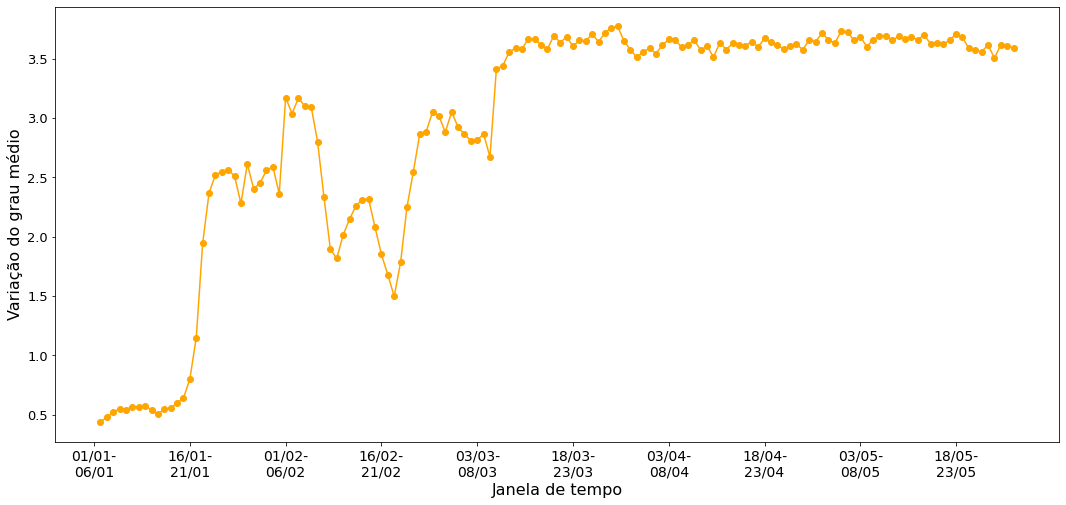

In [8]:

x = [i for i in range(1,j)]  #j é o número total de linhas do csv, incluindo o cabeçalho, por isso o range funciona


plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Variação do grau médio", size = 16)
plt.show()


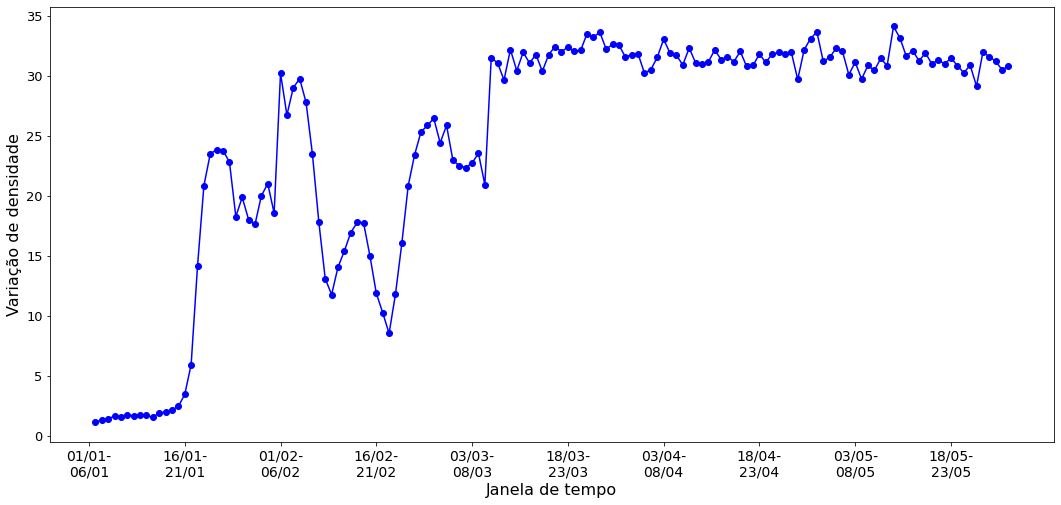

In [19]:
#densidade: blue; degree: orange; C: green; F: red; FragCliques: purple
plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Variação de densidade", size = 16)
plt.show()



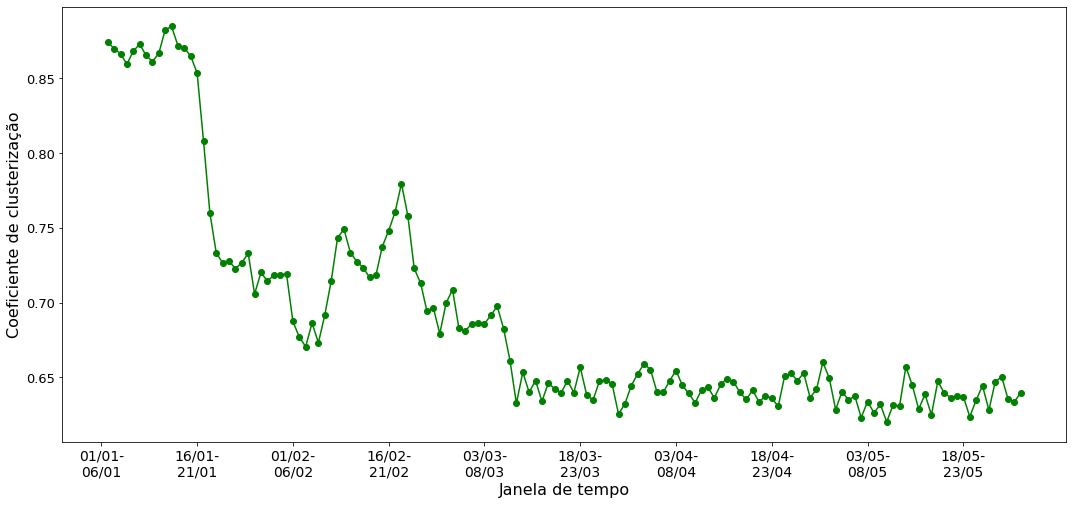

In [20]:
#clustering_coefficient: green, fragmentation = red, frag_cliques = purple

plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Coeficiente de clusterização", size = 16)
plt.show()

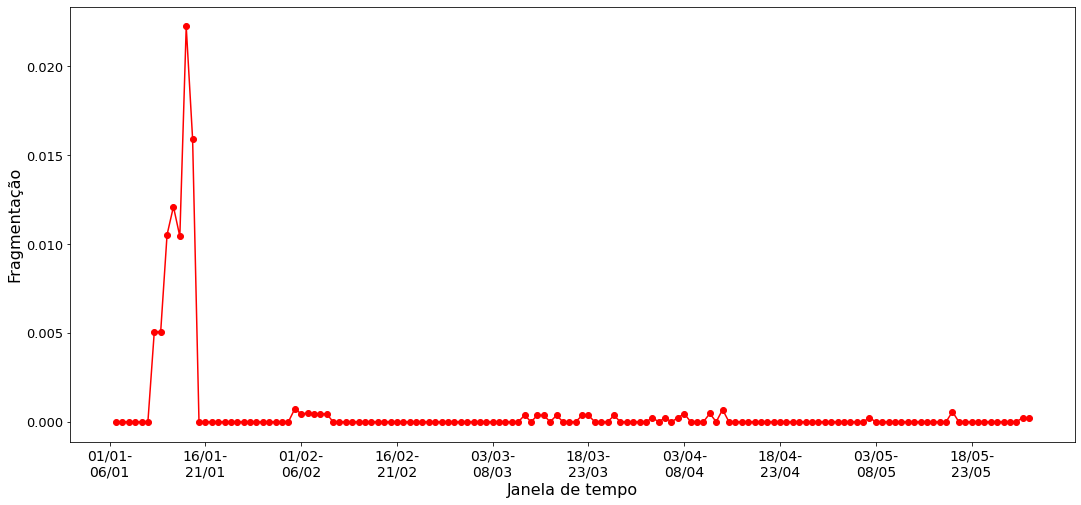

In [9]:
#clustering_coefficient: green, fragmentation = red, frag_cliques = purple
#Fragmentação CORRETA!

plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,metricas['fragmentation'], color = 'red')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Fragmentação", size = 16)
plt.show()

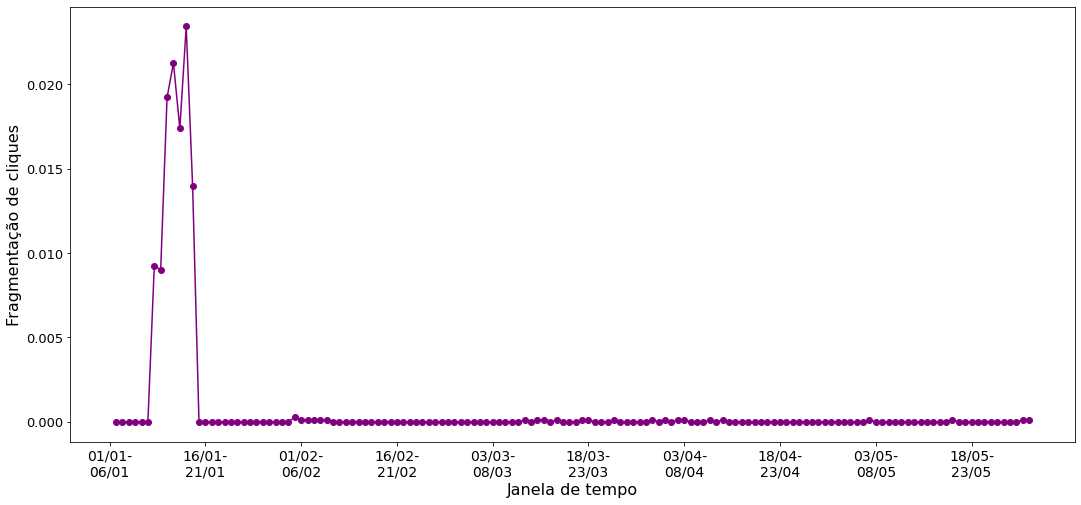

In [23]:
#clustering_coefficient: green, fragmentation = red, frag_cliques = purple

plt.figure(figsize=(18,8))
x_ticks_1 = [0,15,30,45,60,75,90,105,120,135]
x_ticks_2 = ['01/01-\n06/01','16/01-\n21/01','01/02-\n06/02','16/02-\n21/02','03/03-\n08/03','18/03-\n23/03','03/04-\n08/04','18/04-\n23/04','03/05-\n08/05', '18/05-\n23/05']
plt.xticks(x_ticks_1, x_ticks_2, fontsize = 14)
plt.yticks(fontsize = 13)

plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple')


plt.xlabel("Janela de tempo", size = 16)
plt.ylabel("Fragmentação de cliques", size = 16)
plt.show()

# Alguns testes e plots 

In [9]:
networkMetrics.principal(31, 'janeiro_teste')

graph


In [4]:
#faz rede de cliques a partir de arquivo
path = "Janelas/033_4-2_9-2.txt"
arq = open(path)
edges,cliques,qtdNodesInitialState = networkMetrics.extractVectorFromFile(arq)
arq.close()

initial_state_gephi(path,"nodesT33init","edgesT33init")
rede_justaposta_gephi(path,'nodesT33', 'edgesT33')

sucesso, cheque a pasta graph


In [6]:
initial_state_gephi(path,"nodesT33init","edgesT33init")

In [3]:
path = "graph/resultados_base_grande_2020_jan_maio.csv"
metricas,j = plot_metricas_csv2(path)

In [8]:
#fazendo csv so com as métricas interessantes

arq = open('graph/metricas_processadas_jan_maio.csv', 'w+')

arq.write("var_densidade, var_network_degree, clustering_coefficient, fragmentation, frag_cliques\n")

var_densidade = metricas['var_densidade']
var_network_degree = metricas['var_network_degree']
clustering_coefficient = metricas['clustering_coefficient']
fragmentation = metricas['fragmentation']
frag_cliques = metricas['frag_cliques']

for i in range(len(var_densidade)):
    linha = str(var_densidade[i])+", "+str(var_network_degree[i])+", "+str(clustering_coefficient[i])+", "+str(fragmentation[i])+", "+str(frag_cliques[i])+"\n" 
    
    arq.write(linha)

arq.close()

In [6]:
var_densidade

[0.946082250639861,
 1.0408796166954861,
 0.995200173028437,
 1.2375712704818325,
 1.2083786568975747,
 1.23282878866961,
 1.201717835343124,
 1.3151375593417591,
 1.3560339697962562,
 1.1831681347502165,
 1.5333272021213453,
 1.5872512471098146,
 1.7990466574677955,
 2.144066336886662,
 3.1143033237063706,
 5.790610988554428,
 14.907577219979778,
 21.104596807786724,
 23.729076997168967,
 23.850265281467824,
 23.789985730157056,
 22.85041105003618,
 17.419785257398768,
 21.25546139623646,
 19.092759457811322,
 18.94451620603541,
 20.406818709466474,
 21.24764147813145,
 18.21690599984748,
 30.80829740139003,
 28.464048547211156,
 31.58084497470911,
 30.638488648913313,
 29.818219274248733,
 24.170391495345417,
 17.581412454636045,
 12.556263006440075,
 11.017660931660664,
 13.395524706468892,
 14.939799578619047,
 16.491220161764883,
 17.114304762320753,
 17.108058127985053,
 14.03102513602421,
 11.586082551146513,
 9.633683638909043,
 7.741126361355684,
 10.161172054909963,
 14.57256

<Figure size 576x576 with 0 Axes>

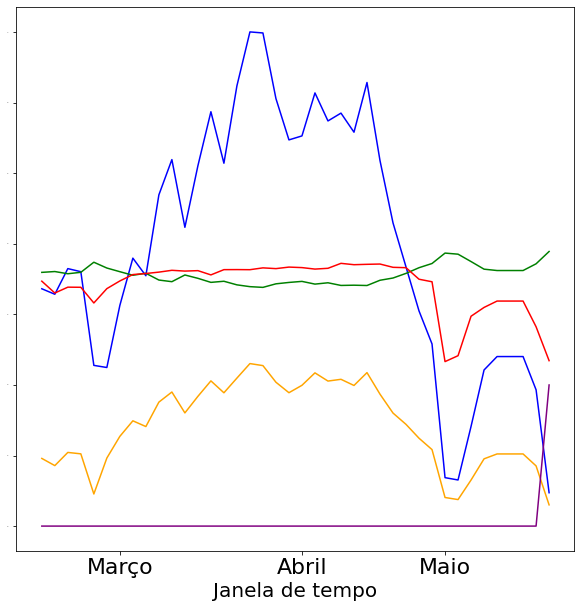

In [27]:
#Plot COVID
path = "graph/deslize_1_resultados_marco_maio_2020.csv"
metricas,j = plot_metricas_csv2(path)
x = [i for i in range(1,j)]
plt.figure(figsize=(8,8))
#x_ticks_1 = [1,5,10,15,20,25,30,35,40]
#x_ticks_2 = ['13/03-\n18/03','18/03-\n23/03','23/03-\n28/03','29/03-\n03/04','03/04-\n08/04','08/04-\n13/04','13/04-\n18/04','13/05-\n18/05','18/05-\n23/05']
x_ticks_1 = [7,21,32]
x_ticks_2 = ['Março', 'Abril', 'Maio']

plt.figure(figsize=(10,10))
plt.xticks(x_ticks_1, x_ticks_2, size = 22)
plt.yticks(size= 0)
#plt.scatter(x,metricas['var_densidade'], color = 'blue')
plt.plot(x,metricas['var_densidade'], color = 'blue', label= 'V('+u"\u0394"+')')
#plt.scatter(x,metricas['var_network_degree'], color = 'orange')
plt.plot(x,metricas['var_network_degree'], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')')
#plt.scatter(x,metricas['clustering_coefficient'], color = 'green')
plt.plot(x,metricas['clustering_coefficient'], color = 'green', label = 'C')
#plt.scatter(x,metricas['fragmentation'], color = 'red')
plt.plot(x,metricas['fragmentation'], color = 'red', label = 'F')
#plt.scatter(x,metricas['frag_cliques'], color = 'purple')
plt.plot(x,metricas['frag_cliques'], color = 'purple', label = 'Fcliques')
#plt.title("variação de densidade 03/2020 a 05/2020")
plt.xlabel("Janela de tempo", size = 20)
#plt.ylabel("Valor das métricas", size = 22)
#plt.legend(prop={'size': 15}, ncol = 5)
plt.show()


(0.0, 1.75)

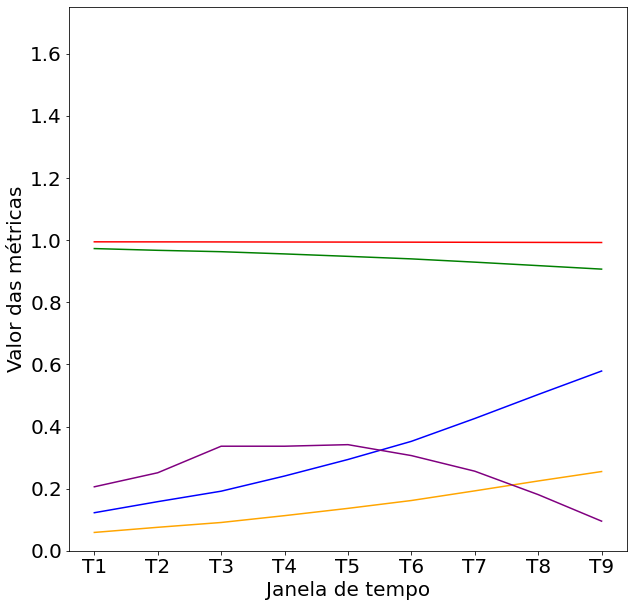

In [68]:
#Desconexa pra conexa PLOT
#PLOTS JUNTOS
#Desconexa pra conexa
x = ["T"+str(i) for i in range(1,10)]
Y = [var_dens_desc_p_conex, var_grau_medio_desc_p_conex, coef_cluster_desc_p_conex, frag_desc_p_conex, frag_cliques_desc_p_conex]

plt.figure(figsize=(10,10))
plt.plot(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens 
#plt.scatter(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens 
plt.plot(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
#plt.scatter(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
plt.plot(x,Y[2], color = 'green', label = 'C') #coef cluster
#plt.scatter(x,Y[2], color = 'green', label = 'C') #coef cluster
plt.plot(x,Y[3], color = 'red', label = 'F') #Fragmentacao
#plt.scatter(x,Y[3], color = 'red', label = 'F') #Fragmentacao
plt.plot(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques
#plt.scatter(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques
plt.xticks(size=20)
plt.xlabel("Janela de tempo", fontsize = 20)
plt.ylabel("Valor das métricas", fontsize = 20)
plt.yticks(size=20)
ax = plt.gca()
ax.set_ylim([0, 1.75])
#plt.legend(prop={'size': 13})

(0.0, 1.77)

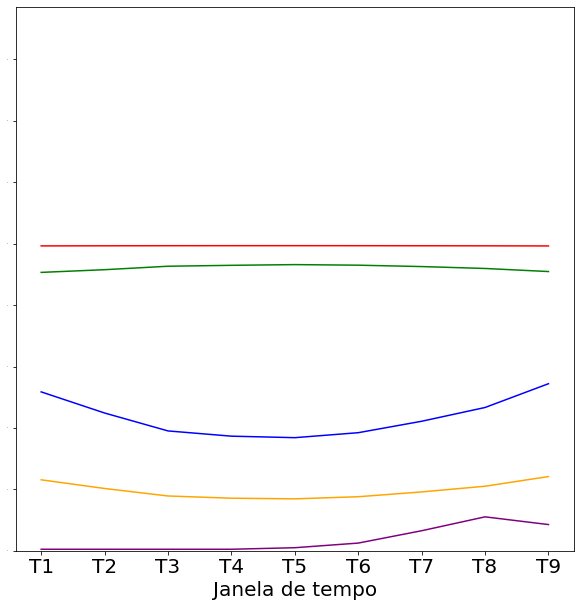

In [65]:
#Conexa pra conexa PLOT

x = ["T"+str(i) for i in range(1,10)]
Y = [var_dens_conex_p_conex, var_grau_medio_conex_p_conex, coef_cluster_conex_p_conex, frag_conex_p_conex, frag_cliques_conex_p_conex]

plt.figure(figsize=(10,10))
plt.plot(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens
#plt.scatter(x,Y[0], color = 'blue', label = 'V('+u"\u0394"+')') #var dens
plt.plot(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
#plt.scatter(x,Y[1], color = 'orange', label = 'V('+u"\u27e8"+'k'+u"\u27e9"+')') #var grau medio
plt.plot(x,Y[2], color = 'green', label = 'C') #coef cluster
#plt.scatter(x,Y[2], color = 'green', label = 'C') #coef cluster
plt.plot(x,Y[3], color = 'red', label = 'F') #Fragmentacao
#plt.scatter(x,Y[3], color = 'red', label = 'F') #Fragmentacao
plt.plot(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques
#plt.scatter(x,Y[4], color = 'purple', label = 'Fcliques') #fragcliques

plt.xticks(size=20)
plt.xlabel("Janela de tempo", fontsize = 20)
#plt.ylabel("Valor das métricas", fontsize = 20)
plt.yticks(size=0)
ax = plt.gca()
ax.set_ylim([0, 1.77])

#plt.legend(prop={'size': 10})

## Testes

In [42]:
reduz_janela("Janelas\TESTE.txt", "Janelas\TESTE_DEST2.txt", 7)

12
inserindo 8
inserindo 2
inserindo 10
inserindo 1
inserindo 9
inserindo 4
inserindo 7
linhas:  ['linha 0\n', 'linha 1\n', 'linha 2\n', 'linha 3\n', 'linha 4\n', 'linha 5\n', 'linha 6\n', 'linha 7\n', 'linha 8\n', 'linha 9\n', 'linha 10\n', 'linha 11\n']
indices:  [1, 2, 4, 7, 8, 9, 10]


In [26]:
rng = np.random.default_rng()

In [18]:
indices = 12 * rng.random((1,7))

indices[0]

array([10.19383006, 11.21747479, 11.05638768,  3.92653636,  4.80413642,
       11.98751915,  7.61569535])

In [27]:
rng.random()

0.8611448267863739

In [31]:
int(rng.random() * 12)

11

In [40]:
l = [6, 5, 3, 2, 4, 9, 11]

l.sort()

l

[2, 3, 4, 5, 6, 9, 11]

In [46]:
#contra-barra (\)
pasta = "BLABLA_blabla"
num=15

origem = pasta+"\T"+str(num)+".txt"
print(origem)

BLABLA_blabla\T15.txt


In [3]:
2+2

4